# Data setup

In [6]:
import pandas as pd
import numpy as np
import seaborn as sns

import matplotlib.pyplot as plt
import math
from sklearn.tree import DecisionTreeClassifier, plot_tree, export_graphviz, export_text, DecisionTreeRegressor
from IPython.display import Image
from sklearn.metrics import accuracy_score, precision_score
from sklearn.metrics import confusion_matrix, classification_report, roc_auc_score
from sklearn.metrics import roc_curve, auc, average_precision_score
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, LabelEncoder, StandardScaler
from sklearn.ensemble import RandomForestRegressor, RandomForestClassifier
from sklearn.metrics import mean_absolute_error, mean_squared_error, accuracy_score, f1_score, confusion_matrix, r2_score
from sklearn.metrics import recall_score

from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [7]:
file_path = "/content/drive/MyDrive/project 6912/Bankrupt data.csv"
df = pd.read_csv(file_path)
df.columns = df.columns.str.strip()
print(df.shape)
print(df.columns)

(6819, 96)
Index(['Bankrupt?', 'ROA(C) before interest and depreciation before interest',
       'ROA(A) before interest and % after tax',
       'ROA(B) before interest and depreciation after tax',
       'Operating Gross Margin', 'Realized Sales Gross Margin',
       'Operating Profit Rate', 'Pre-tax net Interest Rate',
       'After-tax net Interest Rate',
       'Non-industry income and expenditure/revenue',
       'Continuous interest rate (after tax)', 'Operating Expense Rate',
       'Research and development expense rate', 'Cash flow rate',
       'Interest-bearing debt interest rate', 'Tax rate (A)',
       'Net Value Per Share (B)', 'Net Value Per Share (A)',
       'Net Value Per Share (C)', 'Persistent EPS in the Last Four Seasons',
       'Cash Flow Per Share', 'Revenue Per Share (Yuan ¥)',
       'Operating Profit Per Share (Yuan ¥)',
       'Per Share Net profit before tax (Yuan ¥)',
       'Realized Sales Gross Profit Growth Rate',
       'Operating Profit Growth Rate',

In [8]:
df_train = df[:3000]
df_test = df[3000:5000]
df_vals = df[5000:]

# remove target column to create feature only dataset

X_train, X_test, X_vals = df_train.drop('Bankrupt?',axis=1), df_test.drop('Bankrupt?',axis=1), df_vals.drop('Bankrupt?',axis=1)
# store target column
y_train, y_test, y_vals = df_train['Bankrupt?'], df_test['Bankrupt?'], df_vals['Bankrupt?']
print(X_train.shape, y_train.shape)
print(X_test.shape, y_test.shape)
print(X_vals.shape, y_vals.shape)

(3000, 95) (3000,)
(2000, 95) (2000,)
(1819, 95) (1819,)


# Overview

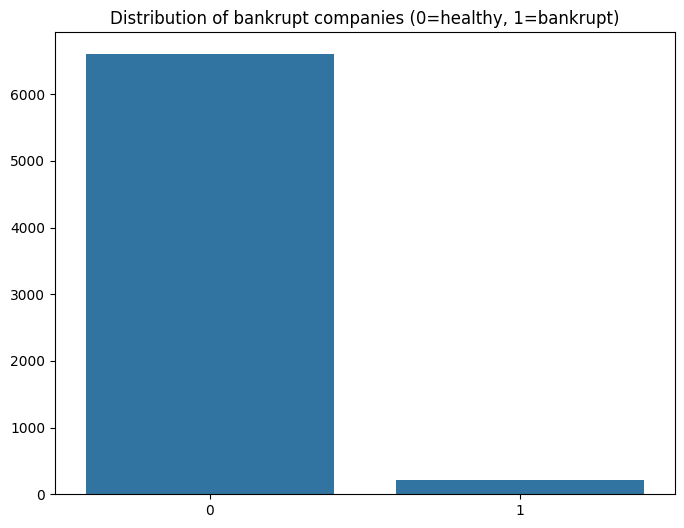

In [9]:

plt.figure(figsize=(8, 6))
sns.countplot(x='Bankrupt?', data=df)
plt.title('Distribution of bankrupt companies (0=healthy, 1=bankrupt)')
plt.xlabel('')
plt.ylabel('')
plt.show()

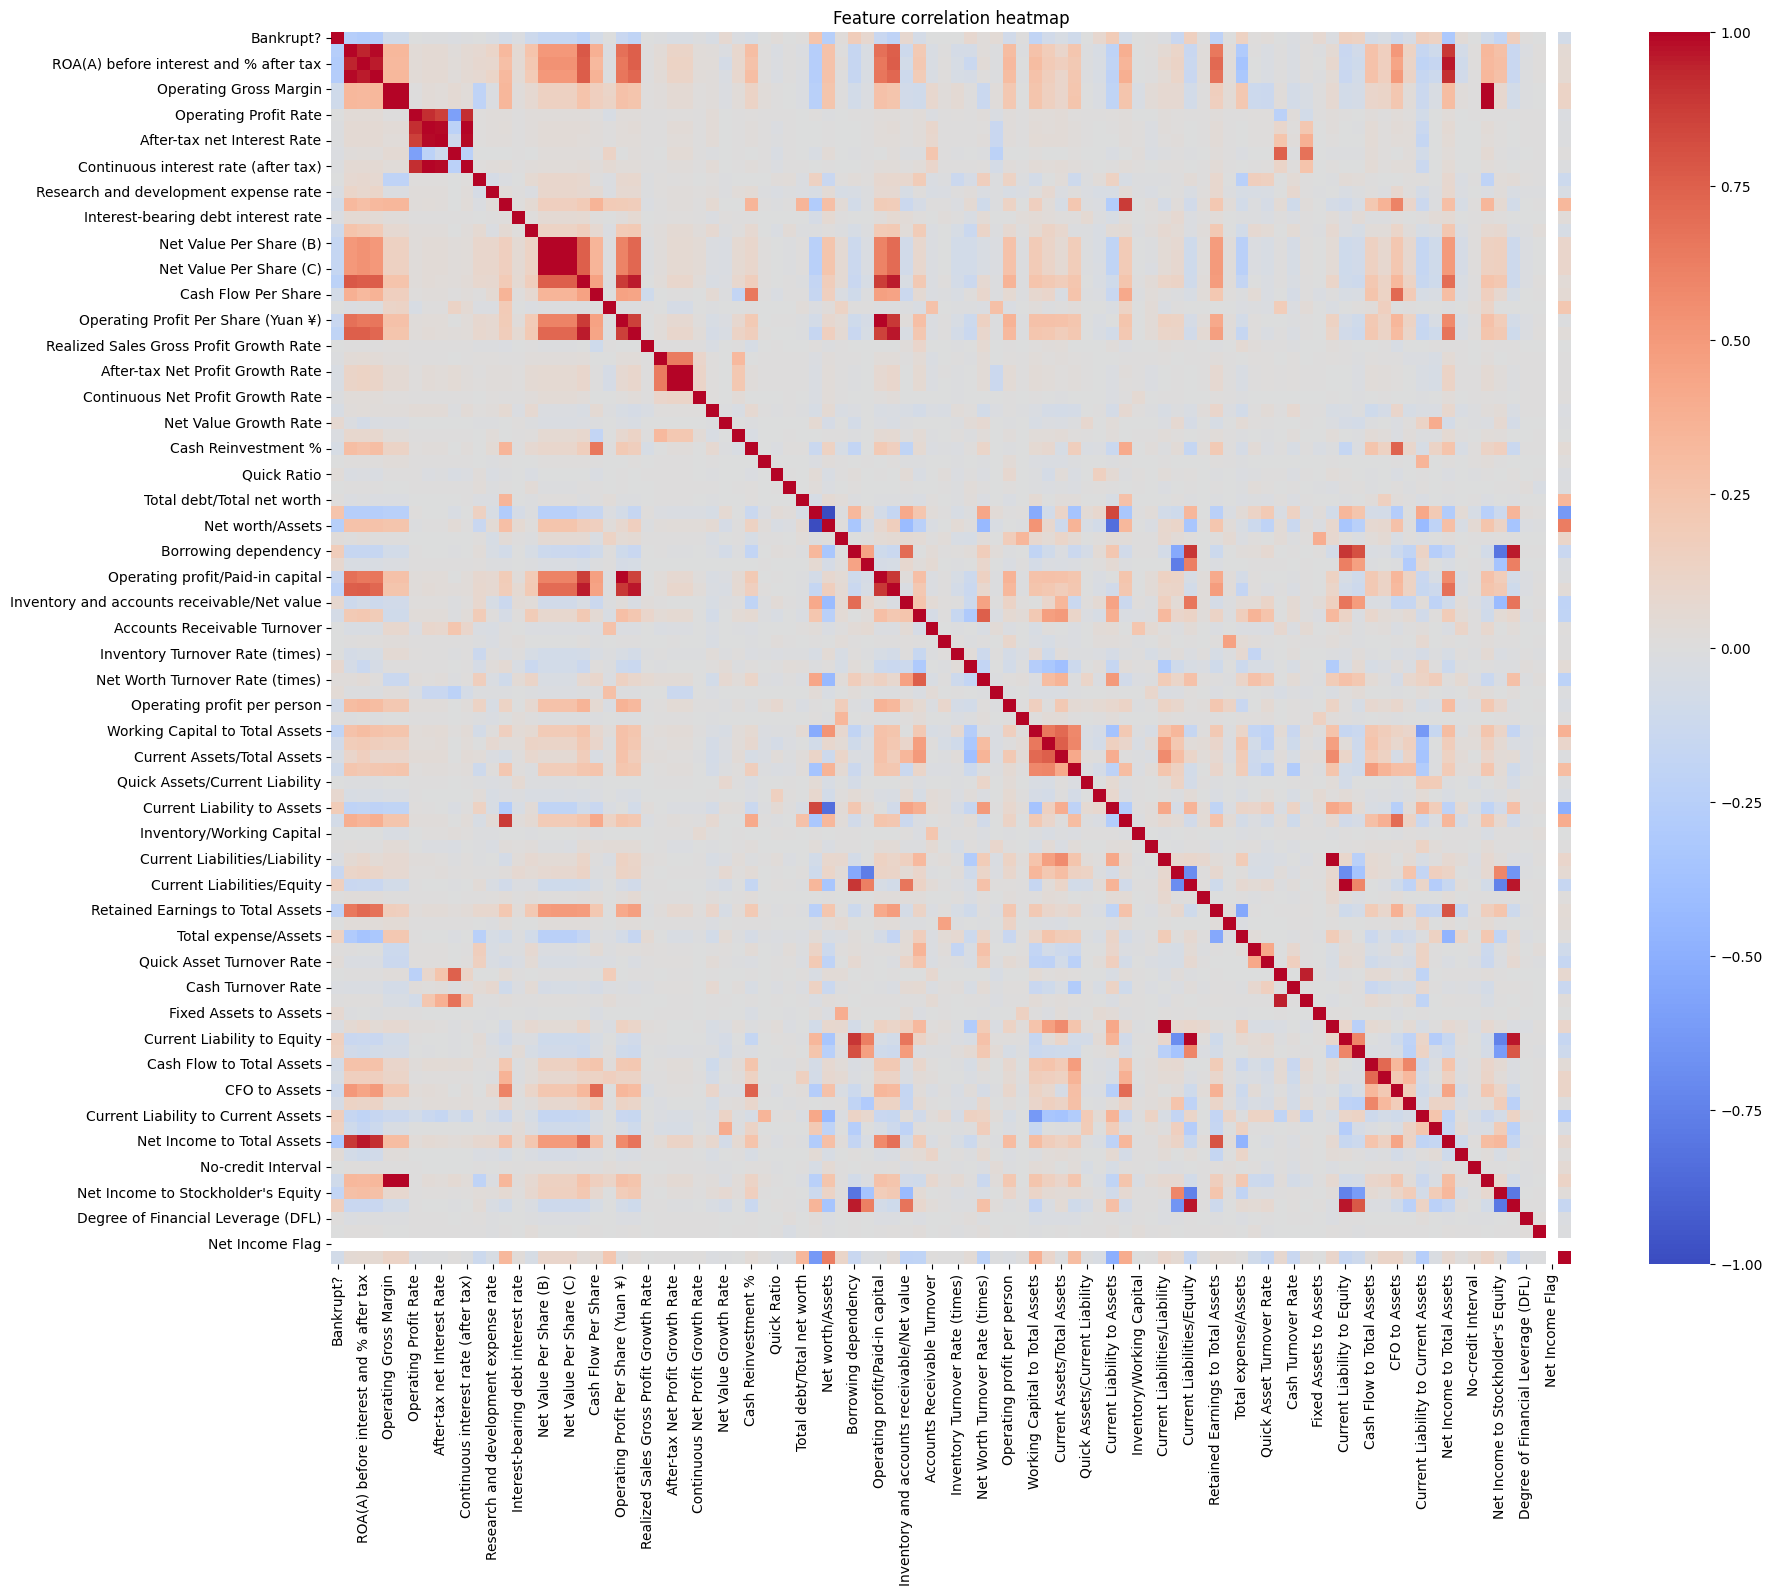

In [10]:
plt.figure(figsize=(20, 16))
corr = df.corr()
sns.heatmap(corr, cmap='coolwarm', center=0)
plt.title('Feature correlation heatmap')
plt.show()

# Decision Tree

(3000, 95) (3000,)
(2000, 95) (2000,)
(1819, 95) (1819,)


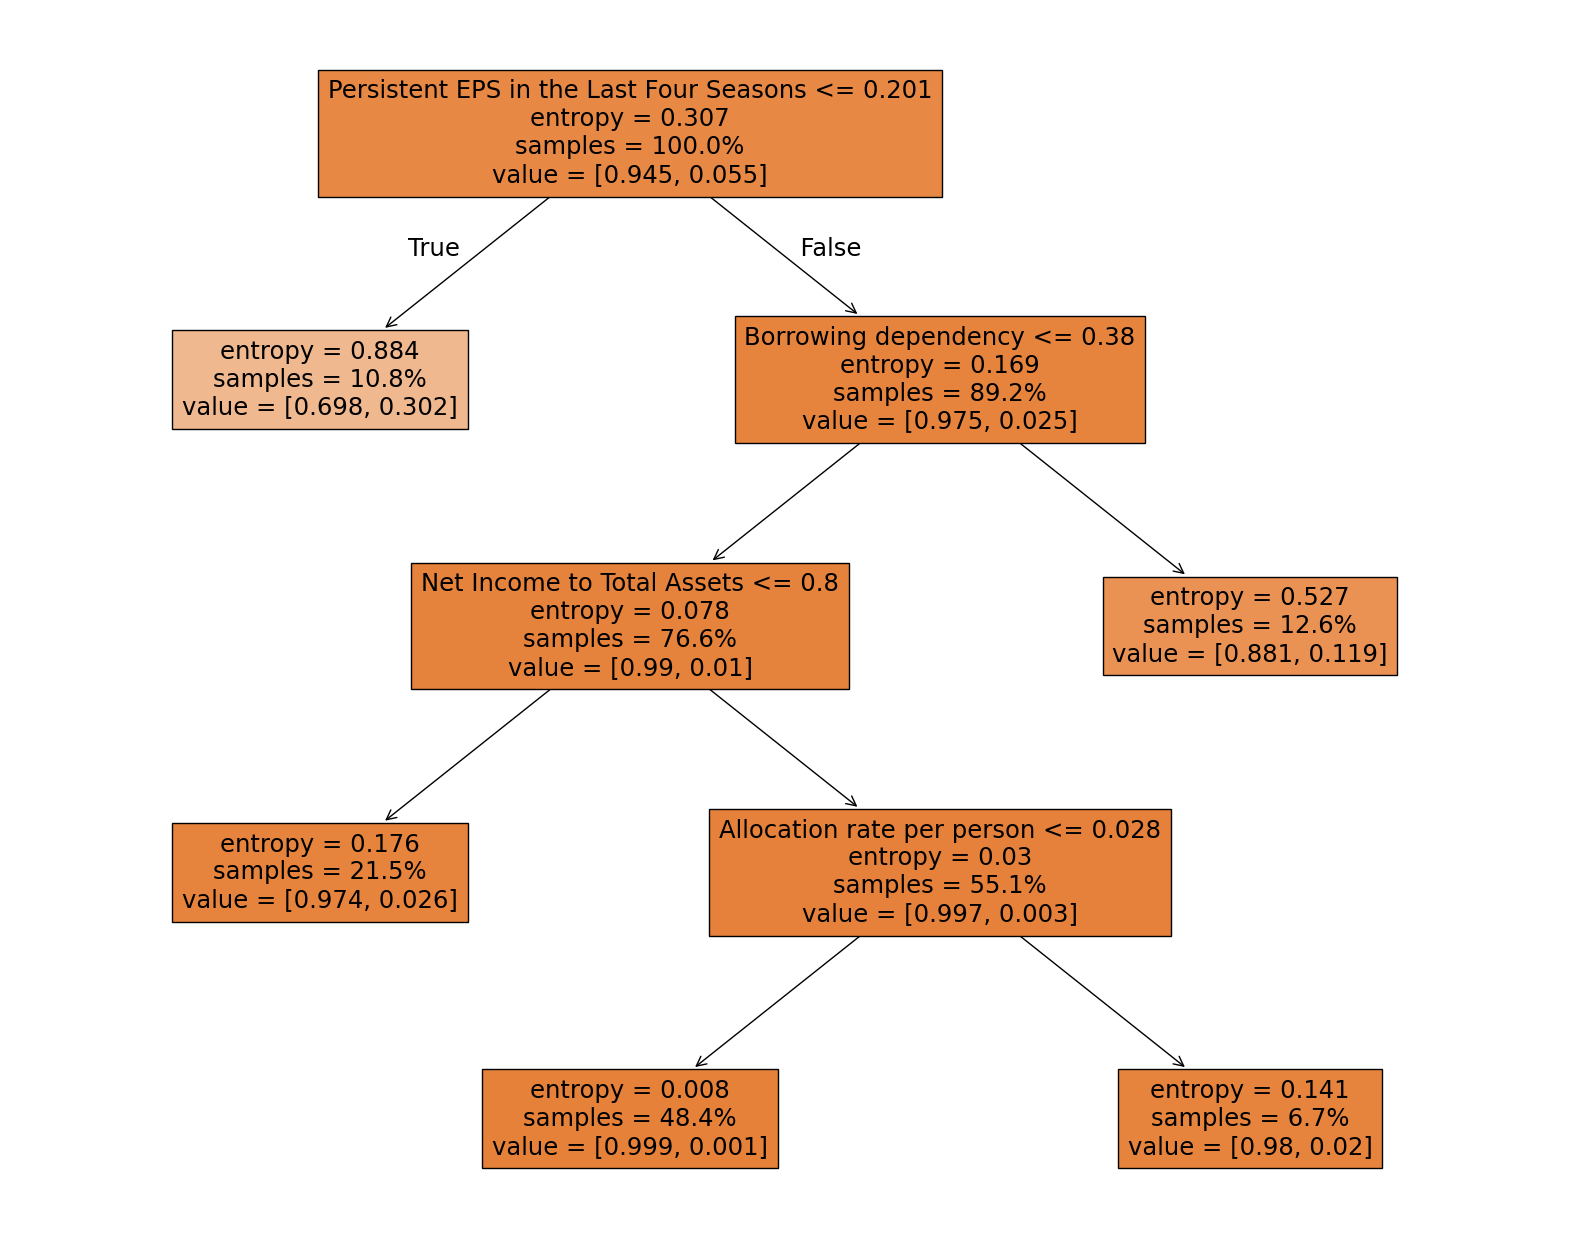

In [11]:
# Define a list of feature column
# We should delete some of the feature here:
selected_features = [
  'Net Value Growth Rate',
  'Net Income to Stockholder\'s Equity',
  'Persistent EPS in the Last Four Seasons',
  'Borrowing dependency',
  'Net profit before tax/Paid-in capital',
  'Non-industry income and expenditure/revenue',
  'Interest Expense Ratio',
  'Net Income to Total Assets',
  'Degree of Financial Leverage (DFL)',
  'Cash/Total Assets',
  'Net Value Per Share (B)',
  ''
]


# Select only these feature columns
#X_train = X_train[selected_features]
#X_test = X_test[selected_features]
#X_vals = X_vals[selected_features]

#X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# Verify the shape
print(X_train.shape, y_train.shape)
print(X_test.shape, y_test.shape)
print(X_vals.shape, y_vals.shape)

clf = DecisionTreeClassifier(criterion='entropy',max_depth=4,min_samples_split=1000,min_samples_leaf=200,random_state=40)
clf = clf.fit(X_train,y_train)
fig, ax = plt.subplots(figsize=(20, 16))
plot_tree(clf, filled=True, feature_names=X_train.columns, proportion=True)
plt.show()

In [12]:
from sklearn.model_selection import GridSearchCV

param_grid = {
    'criterion': ['entropy'],
    'max_depth': [10, 20, 30, 40, 50],
    'min_samples_split': [2, 10, 100, 500, 1000],
    'min_samples_leaf': [ 50, 100, 200],
    'max_features': ['sqrt', 'log2', None]
}

grid_search = GridSearchCV(estimator=clf, param_grid=param_grid, cv=5, n_jobs=-1)
grid_search.fit(X_train, y_train)
best_params = grid_search.best_params_
print('Best Parameters:' , best_params)



Best Parameters: {'criterion': 'entropy', 'max_depth': 10, 'max_features': 'sqrt', 'min_samples_leaf': 50, 'min_samples_split': 500}


## Use the best model

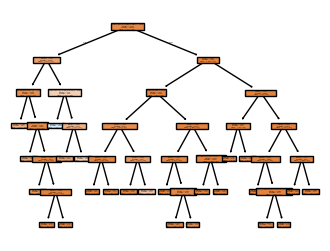

In [13]:
clf = DecisionTreeClassifier(criterion='entropy', max_depth=10, max_features = 'sqrt', min_samples_leaf=50, min_samples_split=2, random_state=40)
clf = clf.fit(X_train,y_train)
fig, ax = plt.subplots(figsize=(4, 3))
plot_tree(clf, filled=True, feature_names=X_train.columns, proportion=True)
plt.show()

##Confusion matrix

(2000,)
[[1948   25]
 [  22    5]]


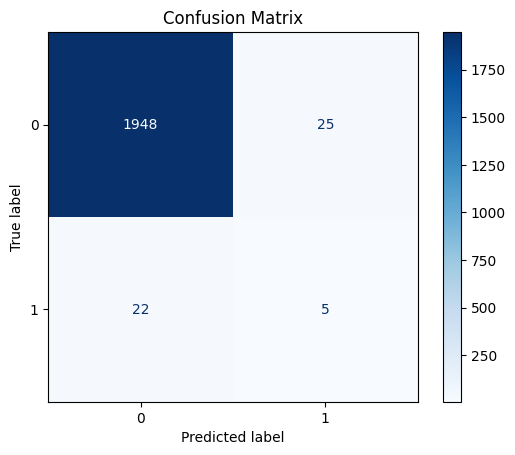

In [14]:

# Confusion Matrix
predictions2 = clf.predict(X_test)
cm3 = confusion_matrix(y_test, predictions2)
print(y_test.shape)
print(cm3)

from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

y_pred = clf.predict(X_test)
cm = confusion_matrix(y_test, y_pred)

disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(cmap=plt.cm.Blues)
plt.title('Confusion Matrix')
plt.show()

##RMSE

In [15]:
y_pred_train=clf.predict(X_train)
mse = mean_squared_error(y_pred_train,y_train)
rmse=math.sqrt(mse)
print("rmse for training set")
print(rmse)

rmse for training set
0.22876479915697986


In [16]:
y_pred_validation=clf.predict(X_vals)
mse = mean_squared_error(y_pred_validation,y_vals)
rmse=math.sqrt(mse)
print("rmse for validation set")
print(rmse)

rmse for validation set
0.12406882411426855


In [17]:
y_pred_test=clf.predict(X_test)
mse = mean_squared_error(y_pred_test,y_test)
rmse=math.sqrt(mse)
print("rmse for test set")
print(rmse)

rmse for test set
0.1532970971675589


## Cost function

In [18]:
y_train_pred = clf.predict_proba(X_train)
print (y_train_pred)
y_val_pred=clf.predict_proba(X_vals)
y_test_pred=clf.predict_proba(X_test)


# Calculate maximum likelihood for training set, validation set, and test set

mle_vector_train = np.log(np.where(y_train == 1, y_train_pred[:,1], y_train_pred[:,0]))
mle_vector_val = np.log(np.where(y_vals == 1, y_val_pred[:,1], y_val_pred[:,0]))
mle_vector_test = np.log(np.where(y_test == 1, y_test_pred[:,1], y_test_pred[:,0]))

# Calculate cost functions from maximum likelihoods

cost_function_training=np.negative(np.sum(mle_vector_train)/len(y_train))
cost_function_val=np.negative(np.sum(mle_vector_val)/len(y_vals))
cost_function_test=np.negative(np.sum(mle_vector_test)/len(y_test))

print (y_train_pred)


print('cost function training set =', cost_function_training)
print('cost function validation set =', cost_function_val)
print('cost function test set =', cost_function_test)


[[0.44736842 0.55263158]
 [0.65517241 0.34482759]
 [0.44736842 0.55263158]
 ...
 [1.         0.        ]
 [1.         0.        ]
 [0.96907216 0.03092784]]
[[0.44736842 0.55263158]
 [0.65517241 0.34482759]
 [0.44736842 0.55263158]
 ...
 [1.         0.        ]
 [1.         0.        ]
 [0.96907216 0.03092784]]
cost function training set = 0.12012954074787884
cost function validation set = inf
cost function test set = inf


<ipython-input-18-f1ef8897427e>:10: RuntimeWarning: divide by zero encountered in log
  mle_vector_val = np.log(np.where(y_vals == 1, y_val_pred[:,1], y_val_pred[:,0]))
<ipython-input-18-f1ef8897427e>:11: RuntimeWarning: divide by zero encountered in log
  mle_vector_test = np.log(np.where(y_test == 1, y_test_pred[:,1], y_test_pred[:,0]))


## Threshold

In [19]:
THRESHOLD = [.75, .80, .85]
results = pd.DataFrame(columns=["THRESHOLD", "accuracy", "true pos rate", "true neg rate", "false pos rate", "precision", "f-score"]) # df to store results
results['THRESHOLD'] = THRESHOLD                                                                           # threshold column
n_test = len(y_test)
Q = clf.predict_proba(X_test)[:,1]

j = 0
for i in THRESHOLD:                                                                                        # iterate over each threshold
                                                                         # fit data to model
    preds = np.where(Q>i, 1, 0)                                       # if prob > threshold, predict 1

    cm = (confusion_matrix(y_test, preds,labels=[1, 0], sample_weight=None)/n_test)*100
    # confusion matrix (in percentage)

    print('Confusion matrix for threshold =',i)
    print(cm)
    print(' ')

    TP = cm[0][0]                                                                                          # True Positives
    FN = cm[0][1]                                                                                          # False Positives
    FP = cm[1][0]                                                                                          # True Negatives
    TN = cm[1][1]                                                                                          # False Negatives

    results.iloc[j,1] = accuracy_score(y_test, preds)
    results.iloc[j,2] = recall_score(y_test, preds)
    results.iloc[j,3] = TN/(FP+TN)                                                                         # True negative rate
    results.iloc[j,4] = FP/(FP+TN)                                                                         # False positive rate
    results.iloc[j,5] = precision_score(y_test, preds)
    results.iloc[j,6] = f1_score(y_test, preds)

    j += 1

print('ALL METRICS')
print(results.T.to_string(header=False))

Confusion matrix for threshold = 0.75
[[ 0.    1.35]
 [ 0.   98.65]]
 
Confusion matrix for threshold = 0.8
[[ 0.    1.35]
 [ 0.   98.65]]
 
Confusion matrix for threshold = 0.85
[[ 0.    1.35]
 [ 0.   98.65]]
 
ALL METRICS
THRESHOLD         0.75     0.8    0.85
accuracy        0.9865  0.9865  0.9865
true pos rate      0.0     0.0     0.0
true neg rate      1.0     1.0     1.0
false pos rate     0.0     0.0     0.0
precision          0.0     0.0     0.0
f-score            0.0     0.0     0.0


/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


## AUC

In [20]:
# Compute the ROC curve and AUC
fpr, tpr, _ = roc_curve(y_test, Q)
roc_auc = auc(fpr,tpr)

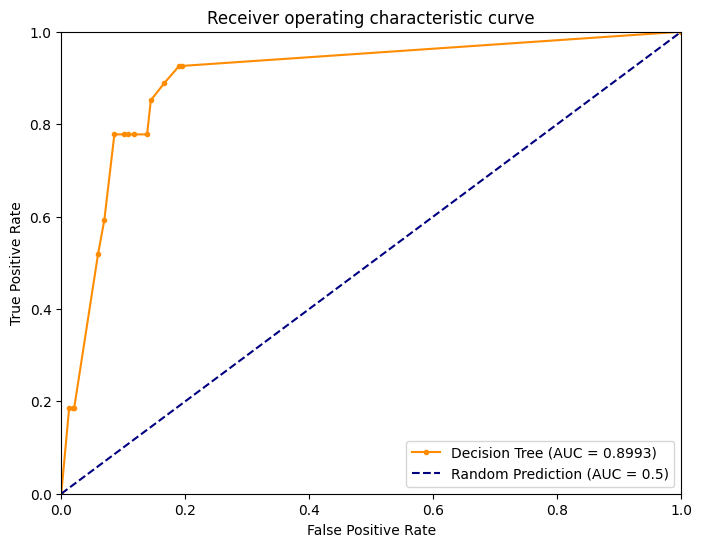

In [21]:
plt.figure(figsize=(8,6))      # format the plot size
lw = 1.5
plt.plot(fpr, tpr, color='darkorange', marker='.',
         lw=lw, label='Decision Tree (AUC = %0.4f)' % roc_auc)
plt.plot([0, 1], [0, 1], color='navy', lw=lw, linestyle='--',
         label='Random Prediction (AUC = 0.5)' )
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.0])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver operating characteristic curve')
plt.legend(loc="lower right")
plt.show()

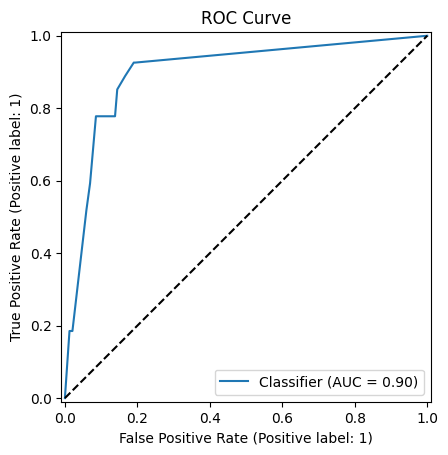

In [22]:
from sklearn.metrics import RocCurveDisplay

y_proba = clf.predict_proba(X_test)[:, 1]
RocCurveDisplay.from_predictions(y_test, y_proba)
plt.plot([0, 1], [0, 1], 'k--')
plt.title('ROC Curve')
plt.show()


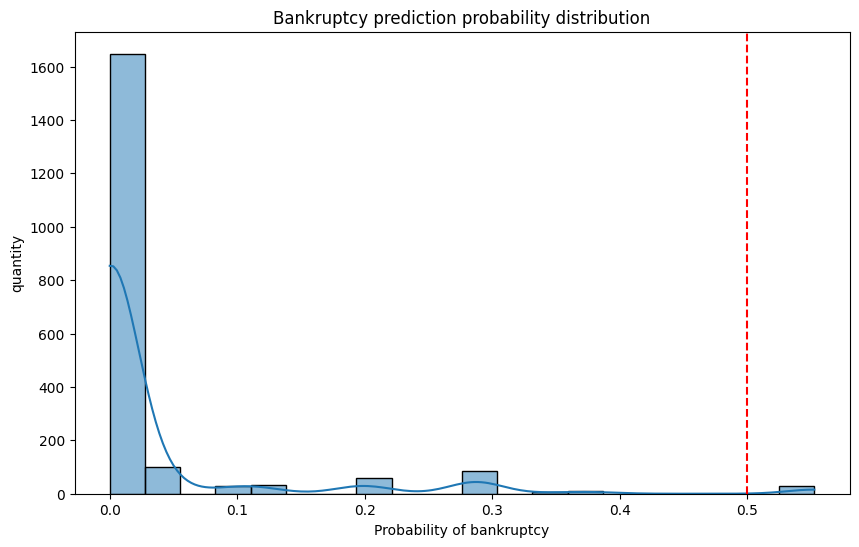

In [23]:
plt.figure(figsize=(10, 6))
sns.histplot(y_proba, bins=20, kde=True)
plt.title('Bankruptcy prediction probability distribution')
plt.xlabel('Probability of bankruptcy')
plt.ylabel('quantity')
plt.axvline(x=0.5, color='r', linestyle='--') # Decision threshold
plt.show()

#Random Forest

In [24]:
# Separating features and target variables
X = df.drop('Bankrupt?', axis=1)
y = df['Bankrupt?']

# Handling missing values ​​(if any)
X = X.fillna(X.mean())

# Standardize the data
# scaler = StandardScaler()
# X_scaled = scaler.fit_transform(X)

# Split training set and test set
#X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

Accuracy: 0.982

Confusion Matrix:
[[1959   14]
 [  22    5]]

Classification Report:
              precision    recall  f1-score   support

           0       0.99      0.99      0.99      1973
           1       0.26      0.19      0.22        27

    accuracy                           0.98      2000
   macro avg       0.63      0.59      0.60      2000
weighted avg       0.98      0.98      0.98      2000



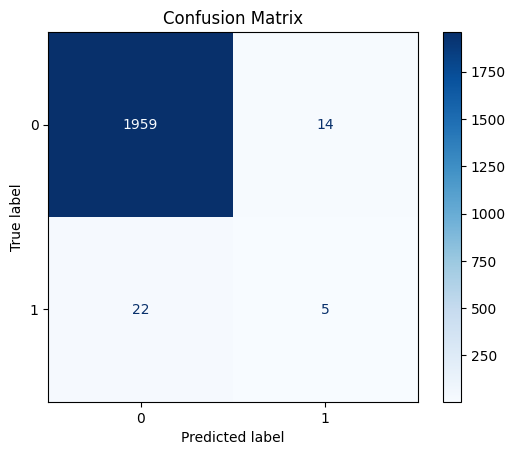

In [25]:
# Creating a Random Forest Classifier
rf = RandomForestClassifier(n_estimators=100, random_state=42)

# Training the model
rf.fit(X_train, y_train)

# Prediction test set
y_pred = rf.predict(X_test)

# Evaluating the Model
print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

y_pred = rf.predict(X_test)
cm = confusion_matrix(y_test, y_pred)

disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(cmap=plt.cm.Blues)
plt.title('Confusion Matrix')
plt.show()

In [26]:
# Get feature importance
feature_importances = pd.DataFrame(rf.feature_importances_,
                                   index = X.columns,
                                   columns=['importance']).sort_values('importance', ascending=False)

print(feature_importances.head(20))  #Show the top 20 features

                                             importance
Borrowing dependency                           0.029115
Net Income to Stockholder's Equity             0.027802
Persistent EPS in the Last Four Seasons        0.026904
Per Share Net profit before tax (Yuan ¥)       0.025831
Net profit before tax/Paid-in capital          0.023931
Net Value Growth Rate                          0.021129
Continuous interest rate (after tax)           0.018108
Interest Expense Ratio                         0.017241
Net Value Per Share (A)                        0.016949
Debt ratio %                                   0.016944
Degree of Financial Leverage (DFL)             0.016879
Liability to Equity                            0.016509
Non-industry income and expenditure/revenue    0.015964
Cash/Current Liability                         0.015773
Total debt/Total net worth                     0.015549
Cash/Total Assets                              0.015138
Net Income to Total Assets                     0

In [27]:
from sklearn.model_selection import GridSearchCV
# Do not run this !!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!

# Defining the parameter grid
param_grid = {
    'n_estimators': [50, 100, 200],
    'max_depth': [10, 20, 30],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4]
}

# Grid Search
grid_search = GridSearchCV(estimator=rf, param_grid=param_grid,
                          cv=5, n_jobs=-1, verbose=2)
grid_search.fit(X_train, y_train)

# Optimal parameters
print("Best Parameters:", grid_search.best_params_)

#Retrain the model using the best parameters
best_rf = grid_search.best_estimator_
y_pred = best_rf.predict(X_test)
print("Optimized Accuracy:", accuracy_score(y_test, y_pred))

Fitting 5 folds for each of 81 candidates, totalling 405 fits


KeyboardInterrupt: 

In [28]:
# Predicting bankruptcy probability (not just class)
y_proba = rf.predict_proba(X_test)[:, 1]  # Get the probability of bankruptcy

# The probability can be converted into a DataFrame for easy viewing
proba_df = pd.DataFrame({'Actual': y_test, 'Predicted_Probability': y_proba})
print(proba_df.head(10))

      Actual  Predicted_Probability
3000       0                   0.00
3001       0                   0.02
3002       0                   0.18
3003       0                   0.05
3004       0                   0.00
3005       0                   0.17
3006       0                   0.00
3007       0                   0.00
3008       0                   0.00
3009       0                   0.00


## Rebuild the model by best parameters

In [29]:
# Create the final model using the best parameters found
final_model = RandomForestClassifier(
    max_depth=10,
    min_samples_leaf=4,
    min_samples_split=10,
    n_estimators=100,
    random_state=42
)

# Retrain on all training data (no need to keep validation set)
final_model.fit(X_train, y_train)

RandomForestClassifier(max_depth=10, min_samples_leaf=4, min_samples_split=10,
                       random_state=42)

Optimized model evaluation:
              precision    recall  f1-score   support

           0       0.99      0.99      0.99      1973
           1       0.24      0.15      0.18        27

    accuracy                           0.98      2000
   macro avg       0.61      0.57      0.59      2000
weighted avg       0.98      0.98      0.98      2000


Confusion Matrix:
[[1960   13]
 [  23    4]]


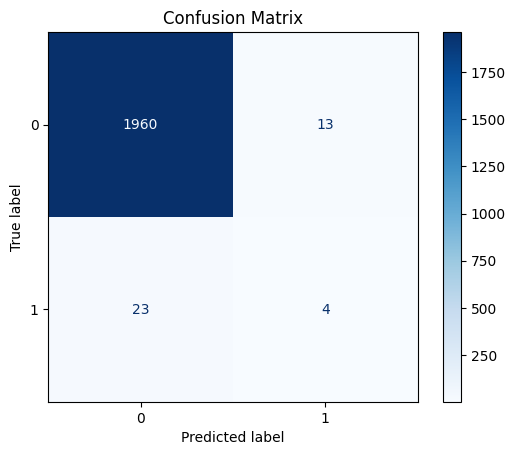

In [30]:
# Prediction test set
y_pred = final_model.predict(X_test)
y_proba = final_model.predict_proba(X_test)[:, 1]  # Get bankruptcy probability

print("Optimized model evaluation:")
print(classification_report(y_test, y_pred))
print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))
cm = confusion_matrix(y_test, y_pred)

disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(cmap=plt.cm.Blues)
plt.title('Confusion Matrix')
plt.show()

## Other Feature

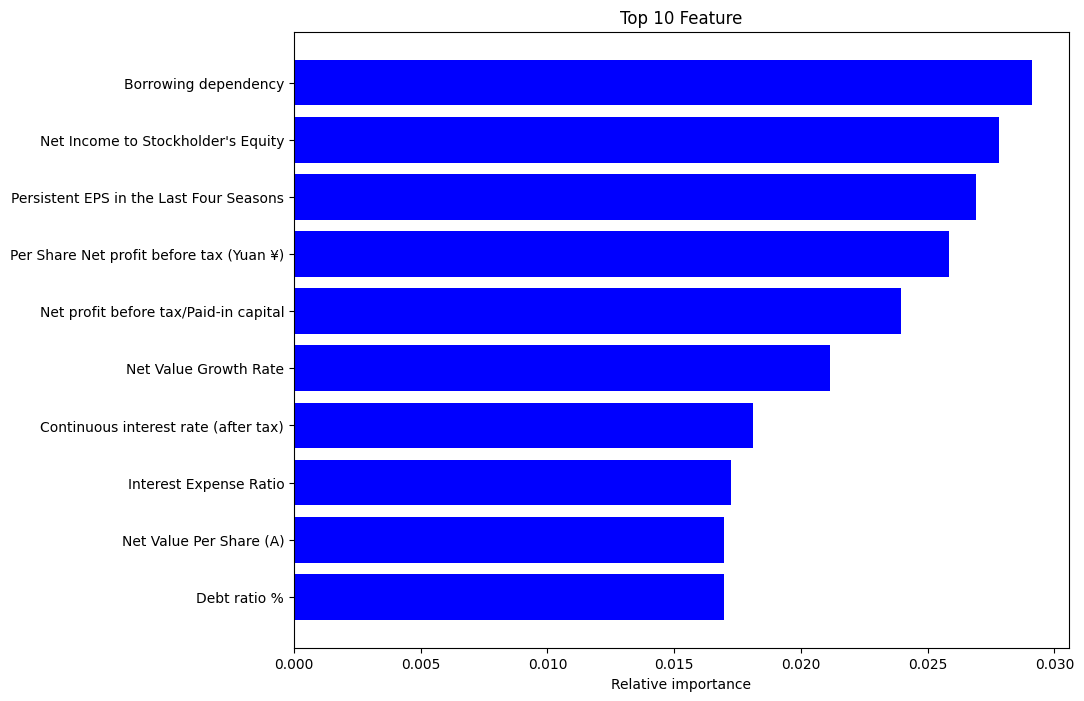

In [34]:
# Get feature importance
importances = rf.feature_importances_
features = X.columns
indices = np.argsort(importances)[-10:]  # Take the 20 most important features

plt.figure(figsize=(10, 8))
plt.title('Top 10 Feature')
plt.barh(range(len(indices)), importances[indices], color='b', align='center')
plt.yticks(range(len(indices)), [features[i] for i in indices])
plt.xlabel('Relative importance')
plt.show()

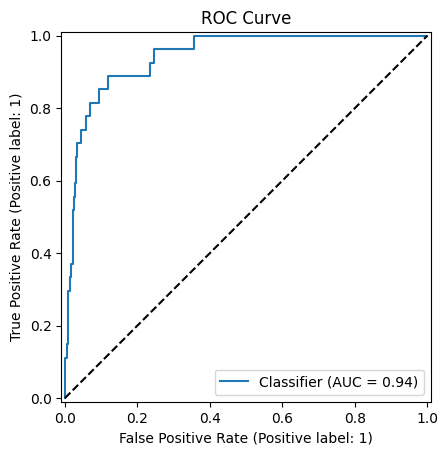

In [32]:
from sklearn.metrics import RocCurveDisplay

y_proba = final_model.predict_proba(X_test)[:, 1]
RocCurveDisplay.from_predictions(y_test, y_proba)
plt.plot([0, 1], [0, 1], 'k--')
plt.title('ROC Curve')
plt.show()



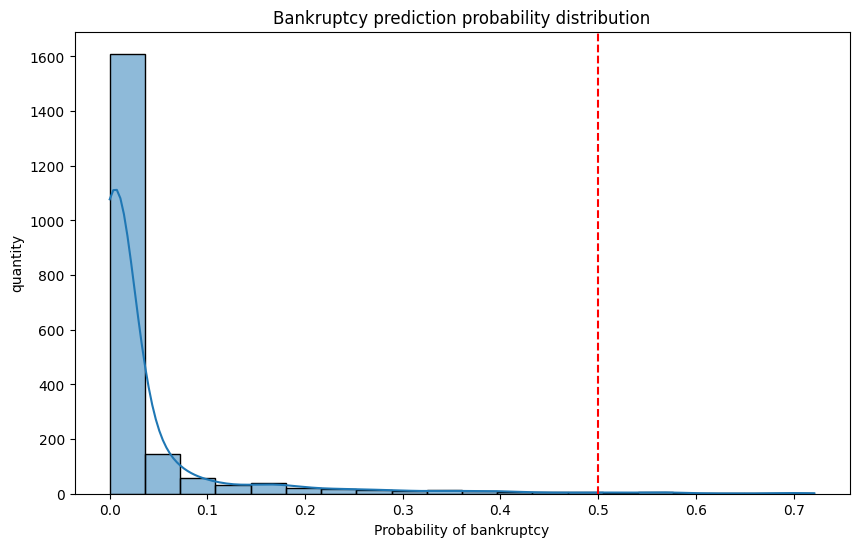

In [33]:
plt.figure(figsize=(10, 6))
sns.histplot(y_proba, bins=20, kde=True)
plt.title('Bankruptcy prediction probability distribution')
plt.xlabel('Probability of bankruptcy')
plt.ylabel('quantity')
plt.axvline(x=0.5, color='r', linestyle='--') # Decision threshold
plt.show()